Import Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage   import uniform_filter1d
import os
import time
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

Input 

In [5]:
#df_train_meta = pd.read_csv("df_train_meta_filtered.csv")
#df_val_meta = pd.read_csv("df_val_meta_filtered.csv")
TRAIN_CSV      = "c:/Users/HP/Downloads/dataset CPICANN/anno_train.csv"
VAL_CSV        = "c:/Users/HP/Downloads/dataset CPICANN/anno_val.csv"
TRAIN_CSV_PATH = "c:/Users/HP/Downloads/Code_CPICANN/df_train_meta_filtered.csv"
TRAIN_BACK_DIR = "c:/Users/HP/Downloads/dataset CPICANN/train_with_back/train_with_back"
COL_DATA_ID     = "dataId"
COL_FORMULA     = "formula"
COL_CRYSTAL_SYS = "crystalSys"

with open("config.json", "r") as f:
    config = json.load(f)
PALETTE = config["PALETTE"]

TWO_THETA_MIN = 10.0
TWO_THETA_MAX = 80.0
N_POINTS      = 4500
CRYSTAL_SYS_MAP    = {0: "Kubik", 1: "Tetragonal", 2: "Ortorombik", 5: "Monoklinik"}
TARGET_CRYSTAL_SYS = [0, 1, 2, 5]
PALETTE_Pola_XRD = ["#2196F3", "#2196F3", "#2196F3", "#2196F3"]

Visualisasi Distribusi Data

Mapping 7 kelas sistem kristal:
 Nilai crystalSys Crystal System
                0          Cubic
                1     Tetragonal
                2   Orthorhombic
                3       Trigonal
                4      Hexagonal
                5     Monoclinic
                6      Triclinic

[TRAIN - 7 KELAS] Total baris              : 553752
[TRAIN - 7 KELAS] Lolos filter ABX3        : 11568
[TRAIN - 7 KELAS] Lolos filter 7 crystalSys: 11568

[VAL   - 7 KELAS] Total baris              : 138438
[VAL   - 7 KELAS] Lolos filter ABX3        : 2892
[VAL   - 7 KELAS] Lolos filter 7 crystalSys: 2892


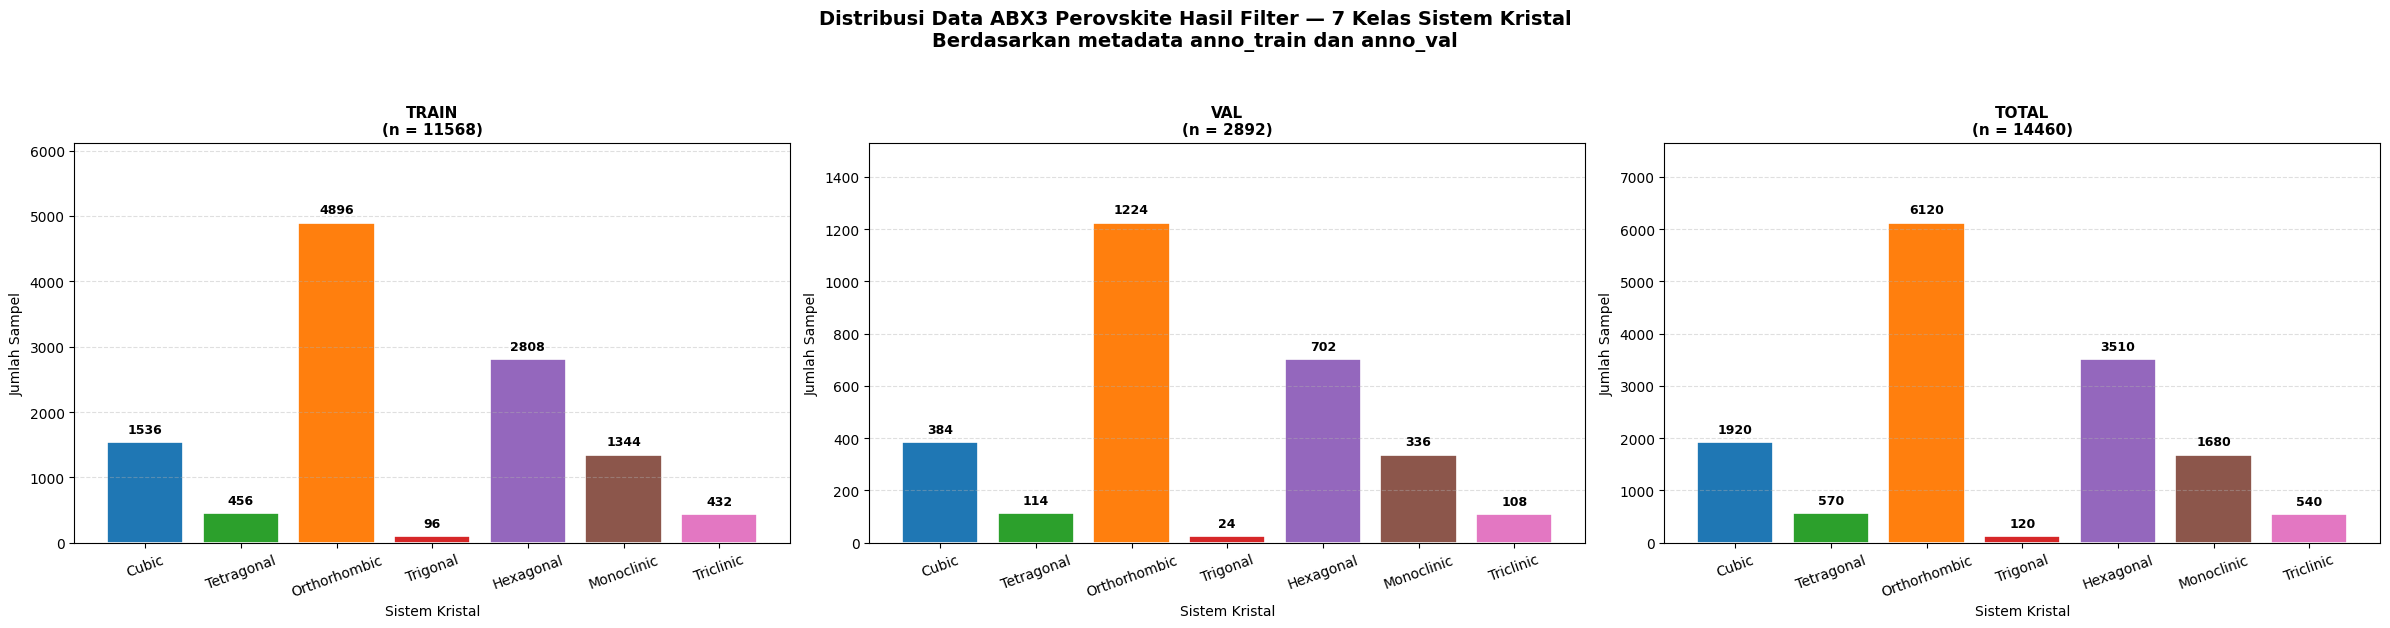

In [15]:
CRYSTAL_SYS_MAP_7 = {
    0: "Cubic",
    1: "Tetragonal",
    2: "Orthorhombic",
    3: "Trigonal",
    4: "Hexagonal",
    5: "Monoclinic",
    6: "Triclinic",
}

PALETTE_7 = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

print("Mapping 7 kelas sistem kristal:")
print(pd.DataFrame({
    "Nilai crystalSys": list(CRYSTAL_SYS_MAP_7.keys()),
    "Crystal System": list(CRYSTAL_SYS_MAP_7.values())
}).to_string(index=False))

A_SITE = {"Li", "Na", "K", "Rb", "Cs", "Mg", "Ca", "Sr", "Ba", "La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu", "Y", "Bi", "Th", "Tl", "Ag", "Cd", "U", "Np", "Pu", "Am", "Cm", "Pa", "Hg"}
B_SITE = {"Sc", "Ti", "V",  "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Hf", "Ta", "W",  "Re", "Os", "Ir", "Pt", "Al", "Ga", "In", "Ge", "Sn", "Pb", "Bi", "Zr", "Si", "Mg", "Cd", "Sc", "Tc", "Au", "Sb", "B"}
X_SITE = {"O", "F", "Cl", "Br", "I", "S", "Se", "Te", "N", "P", "H"}

def parse_formula(formula: str) -> dict:
    s = str(formula)
    for _ in range(20):
        m = re.search(r"\(([^()]+)\)(\d*\.?\d*)", s)
        if not m:
            break
        multiplier = float(m.group(2)) if m.group(2) else 1.0
        inner = ""
        for elem, count in re.findall(r"([A-Z][a-z]?)(\d*\.?\d*)", m.group(1)):
            new_count = (float(count) if count else 1.0) * multiplier
            inner += f"{elem}{new_count:.6g}"
        s = s[:m.start()] + inner + s[m.end():]
    pattern = r"([A-Z][a-z]?)(\d*\.?\d*)"
    elements = {}
    for elem, count in re.findall(pattern, str(formula)):
        count = float(count) if count else 1.0
        elements[elem] = elements.get(elem, 0) + count
    return elements

def is_ABX3(formula: str) -> tuple:
    if not formula or str(formula).strip() in ("", "nan"):
        return False, "Formula kosong"
    elems = parse_formula(formula)
    if not elems:
        return False, "Tidak bisa di-parse"

    unknown = {e for e in elems if e not in A_SITE | B_SITE | X_SITE}
    if unknown:
        return False, f"Elemen tidak dikenali: {unknown}"

    a_elems = {e: n for e, n in elems.items()
               if e in A_SITE and e not in B_SITE}
    b_elems = {e: n for e, n in elems.items() if e in B_SITE}
    x_elems = {e: n for e, n in elems.items() if e in X_SITE}

    n_a = sum(a_elems.values())
    n_b = sum(b_elems.values())
    n_x = sum(x_elems.values())

    if n_a == 0:
        return False, "Tidak ada elemen A-site"
    if n_b == 0:
        return False, "Tidak ada elemen B-site"
    if n_x == 0:
        return False, "Tidak ada elemen X-site"

    ratio_a = n_a / n_b
    ratio_x = n_x / n_b

    if abs(ratio_a - 1.0) <= 0.15 and abs(ratio_x - 3.0) <= 0.30:
        return True, "ABX3"

    return False, f"Rasio A:B:X = {n_a:.2f}:{n_b:.2f}:{n_x:.2f} (bukan ABX3)"



def filter_perovskite_df_7class(csv_path: str, label: str = "dataset") -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    required = [COL_FORMULA, COL_DATA_ID, COL_CRYSTAL_SYS]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom tidak ditemukan: {missing}")

    results = df[COL_FORMULA].apply(is_ABX3)
    df["is_perovskite"] = results.apply(lambda x: x[0])
    df["perovskite_type"] = results.apply(lambda x: x[1])

    df_perov = df[df["is_perovskite"]].copy()
    df_perov = df_perov[df_perov[COL_CRYSTAL_SYS].isin(CRYSTAL_SYS_MAP_7.keys())].copy()
    df_perov["crystal_sys_label_7"] = df_perov[COL_CRYSTAL_SYS].map(CRYSTAL_SYS_MAP_7)

    print(f"\n[{label}] Total baris              : {len(df)}")
    print(f"[{label}] Lolos filter ABX3        : {len(df[df['is_perovskite']])}")
    print(f"[{label}] Lolos filter 7 crystalSys: {len(df_perov)}")
    return df_perov


def count_7class(meta_df: pd.DataFrame) -> pd.Series:
    class_order = list(CRYSTAL_SYS_MAP_7.values())
    return (meta_df[COL_CRYSTAL_SYS]
            .map(CRYSTAL_SYS_MAP_7)
            .value_counts()
            .reindex(class_order, fill_value=0))


df_train_meta_7 = filter_perovskite_df_7class(TRAIN_CSV, label="TRAIN - 7 KELAS")
df_val_meta_7   = filter_perovskite_df_7class(VAL_CSV,   label="VAL   - 7 KELAS")

counts_train_7 = count_7class(df_train_meta_7)
counts_val_7   = count_7class(df_val_meta_7)
counts_total_7 = counts_train_7 + counts_val_7

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle(
    "Distribusi Data ABX3 Perovskite Hasil Filter — 7 Kelas Sistem Kristal\n"
    "Berdasarkan metadata anno_train dan anno_val",
    fontsize=14, fontweight="bold", y=1.04
)

plot_data = [
    (counts_train_7, f"TRAIN\n(n = {int(counts_train_7.sum())})"),
    (counts_val_7,   f"VAL\n(n = {int(counts_val_7.sum())})"),
    (counts_total_7, f"TOTAL\n(n = {int(counts_total_7.sum())})"),
]

for ax, (counts, title) in zip(axes, plot_data):
    labels = list(counts.index)
    values = counts.values
    bars = ax.bar(labels, values, color=PALETTE_7, edgecolor="white", linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Sistem Kristal")
    ax.set_ylabel("Jumlah Sampel")
    y_max = max(values) if len(values) else 0
    ax.set_ylim(0, y_max * 1.25 if y_max > 0 else 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=20)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (y_max * 0.02 if y_max > 0 else 0.05),
            str(int(val)),
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

plt.tight_layout()
plt.show()


Visualisasi Pola XRD


[TRAIN] Mulai loading ...
   Total meta : 8232 baris
   Batch size : 50



Load [TRAIN]: 100%|██████████| 165/165 [04:30<00:00,  1.64s/batch]



   Berhasil   : 8232 / 8232 file
   Tidak ada  : 0
   Shape X    : (8232, 4500)
   Dtype X    : float64


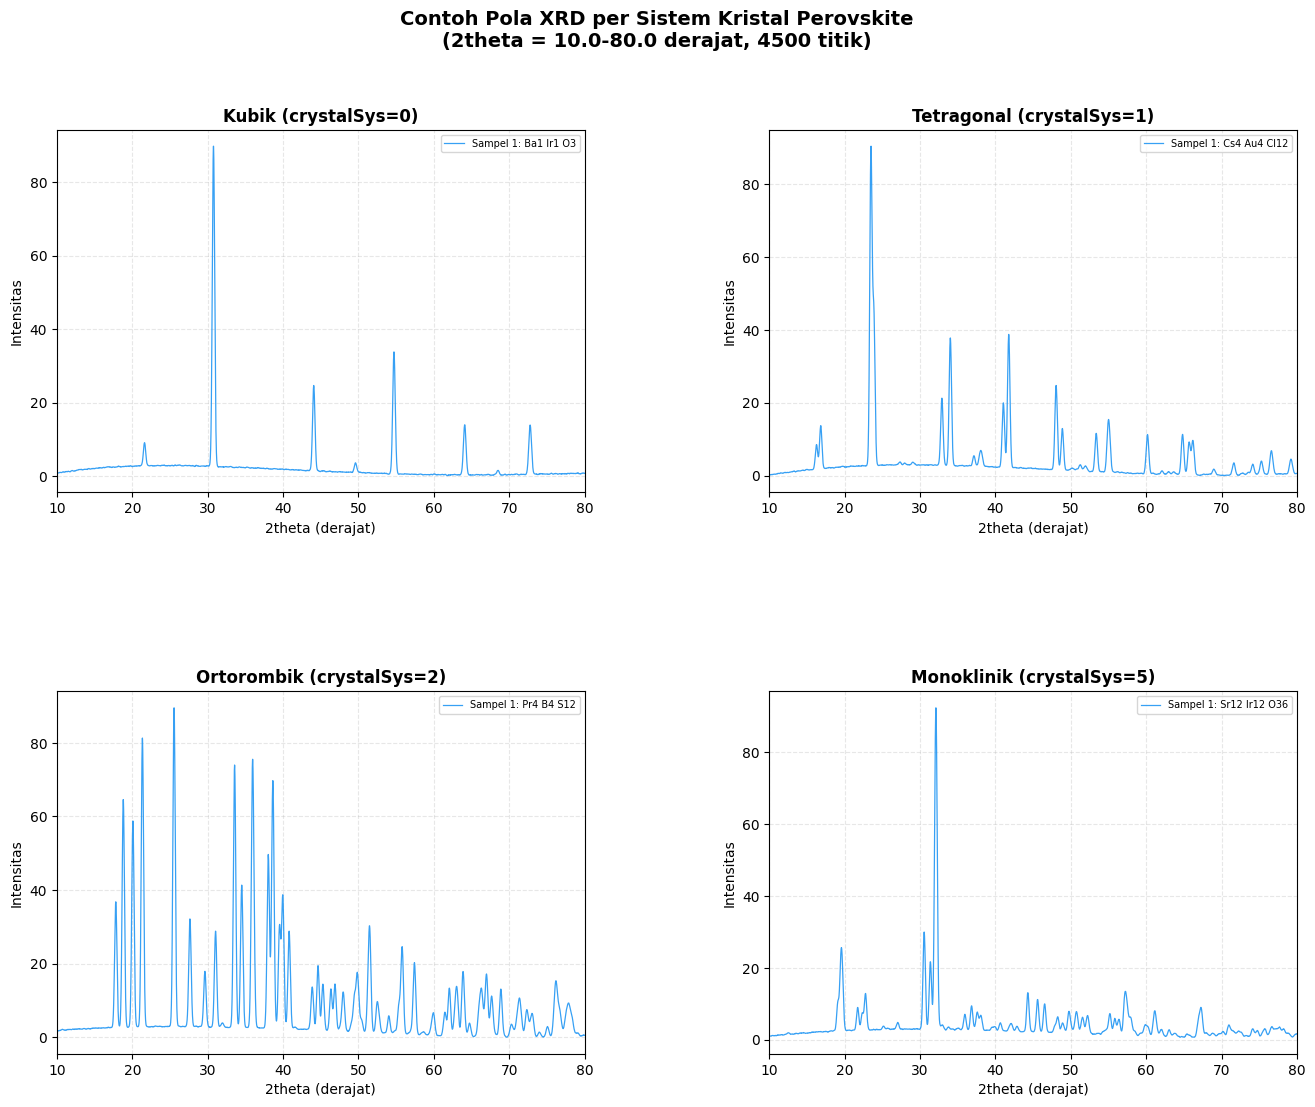

In [6]:
le          = LabelEncoder()
le.classes_ = np.array(sorted(TARGET_CRYSTAL_SYS))
CLASS_NAMES = [CRYSTAL_SYS_MAP[c] for c in le.classes_]
N_CLASSES   = len(CLASS_NAMES)
BATCH_SIZE_LOAD = 50
SLEEP_BETWEEN   = 1.5
MAX_RETRY       = 3
RETRY_DELAY     = 2.0

def load_intensity_safe(data_id: str, folder: str, n_points: int):
    data_id    = str(data_id)
    extensions = [".csv", ".txt", ".xy", ".dat", ""]

    for ext in extensions:
        fpath = os.path.join(folder, data_id + ext)
        if not os.path.isfile(fpath):
            continue
        for attempt in range(1, MAX_RETRY + 1):
            try:
                df_file = pd.read_csv(fpath, header=0)
                if "y" in df_file.columns:
                    arr = df_file["y"].values
                else:
                    arr = df_file.iloc[:, 0].values
                if len(arr) != n_points:
                    old_idx = np.linspace(0, 1, len(arr))
                    new_idx = np.linspace(0, 1, n_points)
                    arr     = np.interp(new_idx, old_idx, arr)
                return arr
            except Exception as e:
                if attempt < MAX_RETRY:
                    time.sleep(RETRY_DELAY)
                else:
                    print(f"\n   Gagal baca {data_id+ext} setelah {MAX_RETRY}x: {e}")
    return None

def load_dataset_batched(meta_df: pd.DataFrame, folder: str,
                         n_points: int, label: str = "dataset") -> tuple:
    print(f"\n[{label}] Mulai loading ...")
    print(f"   Total meta : {len(meta_df)} baris")
    print(f"   Batch size : {BATCH_SIZE_LOAD}\n")

    rows = meta_df.reset_index(drop=True)
    X_list, y_list, ids_list = [], [], []
    not_found = 0

    for batch_start in tqdm(range(0, len(rows), BATCH_SIZE_LOAD),
                            desc=f"Load [{label}]", unit="batch"):
        batch = rows.iloc[batch_start : batch_start + BATCH_SIZE_LOAD]
        for _, row in batch.iterrows():
            arr = load_intensity_safe(row[COL_DATA_ID], folder, n_points)
            if arr is None:
                not_found += 1
            else:
                X_list.append(arr)
                y_list.append(row[COL_CRYSTAL_SYS])
                ids_list.append(row[COL_DATA_ID])
        if batch_start + BATCH_SIZE_LOAD < len(rows):
            time.sleep(SLEEP_BETWEEN)

    if len(X_list) == 0:
        raise ValueError(
            f"[{label}] Tidak ada file yang berhasil dibaca dari {folder}.\n"
            f"Jalankan Sel 7 untuk cek pola nama file."
        )

    X   = np.array(X_list)
    y   = np.array(y_list)
    ids = ids_list

    print(f"\n   Berhasil   : {len(X)} / {len(rows)} file")
    print(f"   Tidak ada  : {not_found}")
    print(f"   Shape X    : {X.shape}")
    print(f"   Dtype X    : {X.dtype}")

    return X, y, ids

train_df = pd.read_csv(TRAIN_CSV_PATH)

X_train_raw, y_train, ids_train = load_dataset_batched(
    train_df, TRAIN_BACK_DIR, N_POINTS, label="TRAIN"
)

# 4. Menggunakan train_df untuk membuat dictionary ID ke Formula
id_to_formula = dict(zip(
    train_df[COL_DATA_ID].astype(str),
    train_df[COL_FORMULA]
))

two_theta  = np.linspace(TWO_THETA_MIN, TWO_THETA_MAX, N_POINTS)
SMOOTH_WIN = 15

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f"Contoh Pola XRD per Sistem Kristal Perovskite\n"
    f"(2theta = {TWO_THETA_MIN}-{TWO_THETA_MAX} derajat, {N_POINTS} titik)",
    fontsize=14, fontweight="bold"
)

gs         = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.35)
n_examples = 1

for idx, (cs_val, cs_name, color) in enumerate(
    zip([0, 1, 2, 5], CLASS_NAMES, PALETTE_Pola_XRD)
):
    ax          = fig.add_subplot(gs[idx // 2, idx % 2])
    mask        = y_train == cs_val
    cls_indices = np.where(mask)[0]
    X_cls       = X_train_raw[mask]

    if len(X_cls) == 0:
        ax.text(0.5, 0.5, "Tidak ada data", transform=ax.transAxes,
                ha="center", va="center", fontsize=12)
        ax.set_title(cs_name)
        continue

    n_show = min(n_examples, len(X_cls))
    for i in range(n_show):
        smoothed = uniform_filter1d(X_cls[i], size=SMOOTH_WIN)
        data_id  = str(ids_train[cls_indices[i]])
        formula  = id_to_formula.get(data_id, data_id)
        ax.plot(two_theta, smoothed, color=color,
                alpha=0.9 - i * 0.2, linewidth=0.9,
                label=f"Sampel {i+1}: {formula}")

    ax.set_title(f"{cs_name} (crystalSys={cs_val})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("2theta (derajat)")
    ax.set_ylabel("Intensitas")
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(linestyle="--", alpha=0.3)

plt.show()